In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

import joblib


In [4]:
# Dataset 1: numeric labels
df1 = pd.read_csv("./dataset/new_data_urls.csv")  
# columns: url, status

# Dataset 2: string labels
df2 = pd.read_csv("./dataset/URL dataset.csv")  
# columns: url, type

print("Dataset 1:")
print(df1.head())

print("\nDataset 2:")
print(df2.head())


Dataset 1:
                                       url  status
0  0000111servicehelpdesk.godaddysites.com       0
1     000011accesswebform.godaddysites.com       0
2                             00003.online       0
3      0009servicedeskowa.godaddysites.com       0
4                     000n38p.wcomhost.com       0

Dataset 2:
                         url        type
0     https://www.google.com  legitimate
1    https://www.youtube.com  legitimate
2   https://www.facebook.com  legitimate
3      https://www.baidu.com  legitimate
4  https://www.wikipedia.org  legitimate


In [5]:
# Rename columns to common format
df1 = df1.rename(columns={"status": "label"})
df2 = df2.rename(columns={"type": "label"})

# Keep only required columns
df1 = df1[["url", "label"]]
df2 = df2[["url", "label"]]


In [6]:
# Mapping string labels to numeric
label_mapping = {
    "phishing": 1,
    "malicious": 1,
    "fraud": 1,
    "spam": 1,
    "suspicious": 1,
    "legitimate": 0,
    "benign": 0,
    "safe": 0,
    "good": 0
}

df2["label"] = df2["label"].astype(str).str.lower().map(label_mapping)

# Remove unknown labels
df2 = df2.dropna()
df2["label"] = df2["label"].astype(int)


In [7]:
print("Dataset 1 Label Distribution:")
print(df1["label"].value_counts())

print("\nDataset 2 Label Distribution:")
print(df2["label"].value_counts())


Dataset 1 Label Distribution:
label
1    427028
0    394982
Name: count, dtype: int64

Dataset 2 Label Distribution:
label
0    345738
1    104438
Name: count, dtype: int64


In [8]:
df = pd.concat([df1, df2], axis=0)

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Merged dataset shape:", df.shape)
print(df.head())


Merged dataset shape: (1272186, 2)
                                                 url  label
0                   facebook.com/joseph.visualartist      1
1  https://www.tasteofcountry.com/tags/jeffrey-st...      0
2                   https://www.socialwork.sdsu.edu/      0
3  http://dookang.co.kr/wp-includes/css/pus/payus...      0
4        http://www.kruoil.com/wp-content/frame.html      1


In [9]:
print("Final Label Distribution:")
print(df["label"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())


Final Label Distribution:
label
0    740720
1    531466
Name: count, dtype: int64

Missing Values:
url      0
label    0
dtype: int64


In [10]:
X = df["url"].astype(str)   # ORIGINAL URL
y = df["label"]

print(X.head())


0                     facebook.com/joseph.visualartist
1    https://www.tasteofcountry.com/tags/jeffrey-st...
2                     https://www.socialwork.sdsu.edu/
3    http://dookang.co.kr/wp-includes/css/pus/payus...
4          http://www.kruoil.com/wp-content/frame.html
Name: url, dtype: object


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 1017748
Test size: 254438


C:\Users\Shreedhar Khorate\AppData\Local\Temp\ipykernel_24196\346347485.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Shreedhar Khorate\AppData\Local\Temp\ipykernel_24196\346347485.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


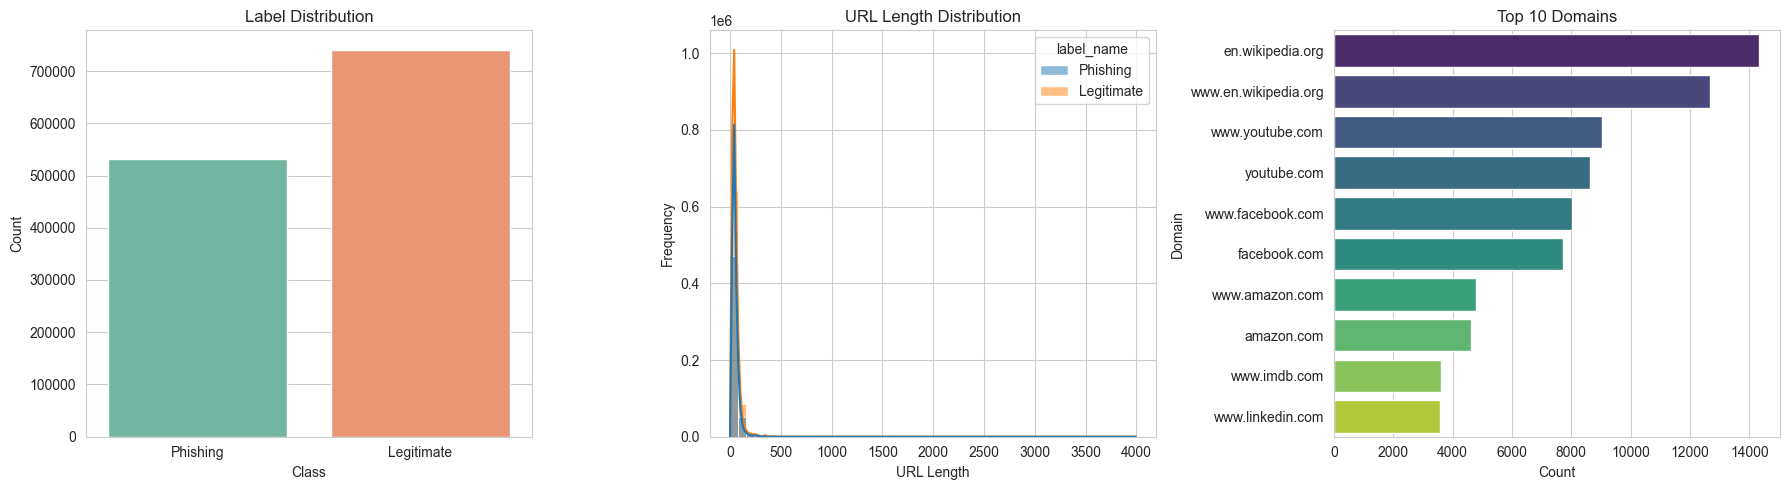

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

sns.set_style("whitegrid")

# Map labels to names
df["label_name"] = df["label"].map({0: "Legitimate", 1: "Phishing"})

# URL length
df["url_length"] = df["url"].str.len()

# Extract domain
def extract_domain(url):
    try:
        domain = urlparse(url).netloc
        return domain if domain else url.split('/')[0]
    except:
        return url.split('/')[0]

df["domain"] = df["url"].apply(extract_domain)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Label distribution
sns.countplot(
    x="label_name",
    data=df,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# 2. URL length distribution
sns.histplot(
    data=df,
    x="url_length",
    hue="label_name",
    bins=50,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("URL Length Distribution")
axes[1].set_xlabel("URL Length")
axes[1].set_ylabel("Frequency")

# 3. Top domains
top_domains = df["domain"].value_counts().head(10)
sns.barplot(
    x=top_domains.values,
    y=top_domains.index,
    palette="viridis",
    ax=axes[2]
)
axes[2].set_title("Top 10 Domains")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Domain")

plt.tight_layout()
plt.show()


In [16]:
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=30000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)


KeyboardInterrupt: 

In [ ]:
model = LinearSVC()
model.fit(X_train_tfidf, y_train)

print("✅ Model trained successfully")


✅ Model trained successfully


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9351354750469663

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94    148144
           1       0.92      0.93      0.92    106294

    accuracy                           0.94    254438
   macro avg       0.93      0.93      0.93    254438
weighted avg       0.94      0.94      0.94    254438



In [ ]:
def predict_url(url):
    vec = vectorizer.transform([url])
    pred = model.predict(vec)[0]
    return "Suspicious" if pred == 1 else "Legitimate"


In [ ]:
print(predict_url("https://www.google.com"))
print(predict_url("http://secure-login-paypal.verify-user.com"))
print(predict_url("https://bank-update-alert-login.com"))


Legitimate
Legitimate
Legitimate


In [ ]:
joblib.dump(model, "phishing_url_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("✅ Model and vectorizer saved")


✅ Model and vectorizer saved
